# Q6 — Investigational drugs: orforglipron, retatrutide, CagriSema

**Question.** For the three big investigational GLP-1-class drugs:
- Active vs completed trial counts
- Phase breakdown
- Expected completion timeline (Gantt-style)

**Note on data scoping.** `drug_query` only contains `orforglipron` and `retatrutide`. CagriSema (`cagrilintide-semaglutide`) doesn't appear under `drug_query` at all — it shows up under `brief_title` instead. We search both columns to recover it.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.dates import DateFormatter, YearLocator

from src.load_data import load_clinical_trials
from src.plotting import apply_style, save_fig, save_table

apply_style()

## 1. Tag rows by investigational drug name

Search both `drug_query` and `brief_title` for each name (case-insensitive). One trial can hit multiple names (e.g. a CagriSema trial mentions both `cagrilintide` and `semaglutide`); we keep the most specific tag.

In [2]:
trials = load_clinical_trials()

# Most-specific first so the .where chain picks the right one.
patterns = {
    "CagriSema":    r"cagrisema|cagri.?sema|cagrilintide",
    "orforglipron": r"orforglipron",
    "retatrutide":  r"retatrutide",
}

haystack = (
    trials["drug_query"].fillna("") + " " + trials["brief_title"].fillna("")
).str.lower()

trials["inv_drug"] = np.nan
for label, pattern in patterns.items():
    mask = haystack.str.contains(pattern, regex=True, na=False)
    trials.loc[mask & trials["inv_drug"].isna(), "inv_drug"] = label

inv = trials[trials["inv_drug"].notna()].copy()
print("Trials per investigational drug (first-match wins):")
print(inv["inv_drug"].value_counts())
print(f"\nTotal investigational trials: {len(inv):,}")

Trials per investigational drug (first-match wins):
inv_drug
orforglipron    45
CagriSema       32
retatrutide     29
Name: count, dtype: int64

Total investigational trials: 106


C:\Users\Dorsa\AppData\Local\Temp\ipykernel_25400\2999983083.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CagriSema' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  trials.loc[mask & trials["inv_drug"].isna(), "inv_drug"] = label


## 2. Status breakdown (active vs completed)

Collapse the 9 ClinicalTrials.gov statuses into 4 buckets that humans actually use.

In [3]:
status_bucket = {
    "COMPLETED": "Completed",
    "RECRUITING": "Active",
    "ACTIVE_NOT_RECRUITING": "Active",
    "NOT_YET_RECRUITING": "Planned",
    "ENROLLING_BY_INVITATION": "Active",
    "TERMINATED": "Stopped",
    "WITHDRAWN": "Stopped",
    "SUSPENDED": "Stopped",
    "UNKNOWN": "Unknown",
}
inv["status_bucket"] = inv["overall_status"].map(status_bucket).fillna("Unknown")

status_tbl = (
    inv.groupby(["inv_drug", "status_bucket"]).size()
       .unstack("status_bucket").fillna(0).astype(int)
)
save_table(status_tbl.reset_index(), "q6_status_breakdown")
status_tbl

status_bucket,Active,Completed,Planned
inv_drug,,,
CagriSema,10,18,4
orforglipron,14,31,0
retatrutide,14,15,0


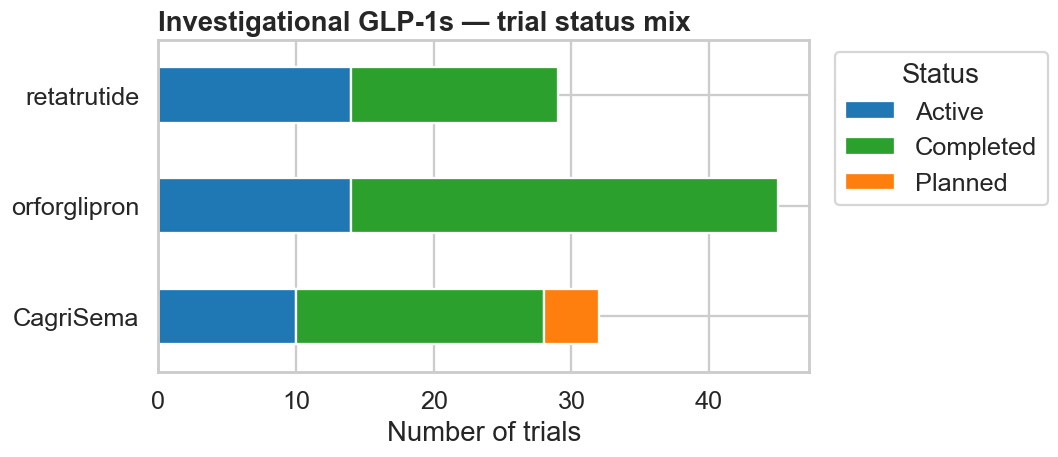

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
status_tbl.plot(
    kind="barh", stacked=True, ax=ax,
    color={"Completed": "#2ca02c", "Active": "#1f77b4",
           "Planned": "#ff7f0e", "Stopped": "#d62728", "Unknown": "#888888"},
)
ax.set_xlabel("Number of trials")
ax.set_ylabel("")
ax.set_title("Investigational GLP-1s — trial status mix")
ax.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_fig(fig, "q6_status_breakdown")
plt.show()

## 3. Phase breakdown

In [5]:
phase_tbl = (
    inv.fillna({"phase": "UNKNOWN"}).groupby(["inv_drug", "phase"]).size()
       .unstack("phase").fillna(0).astype(int)
)
preferred = ["EARLY_PHASE1", "PHASE1", "PHASE1, PHASE2", "PHASE2", "PHASE2, PHASE3", "PHASE3", "PHASE4", "UNKNOWN"]
phase_tbl = phase_tbl[[c for c in preferred if c in phase_tbl.columns]]
save_table(phase_tbl.reset_index(), "q6_phase_breakdown")
phase_tbl

phase,PHASE1,PHASE2,PHASE3
inv_drug,,,
CagriSema,10,5,17
orforglipron,21,1,23
retatrutide,13,3,13


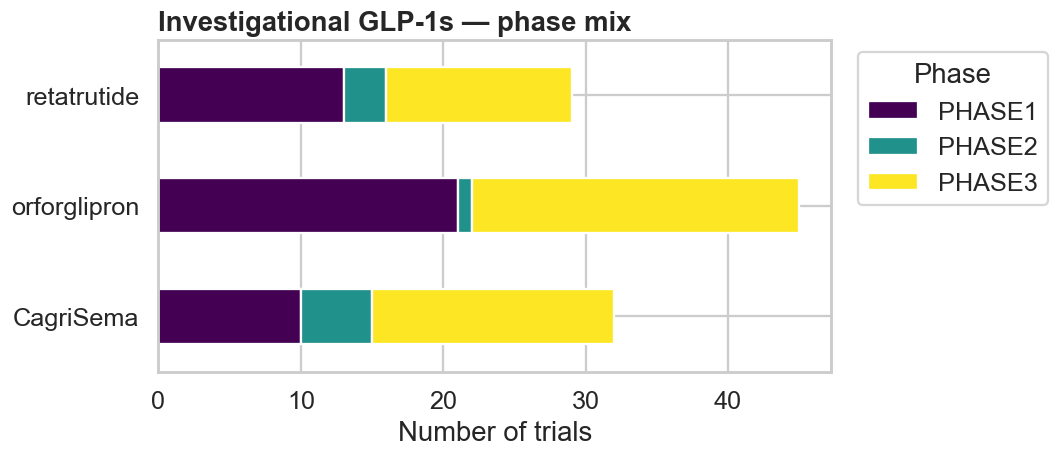

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
phase_tbl.plot(kind="barh", stacked=True, ax=ax, colormap="viridis")
ax.set_xlabel("Number of trials")
ax.set_ylabel("")
ax.set_title("Investigational GLP-1s — phase mix")
ax.legend(title="Phase", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_fig(fig, "q6_phase_breakdown")
plt.show()

## 4. Gantt-style timeline

Each trial = a horizontal bar from `start_date` to `completion_date`. Coloured by drug. Sorted by start date so the eye reads earliest-to-latest.

Trials with valid start+completion dates: 79


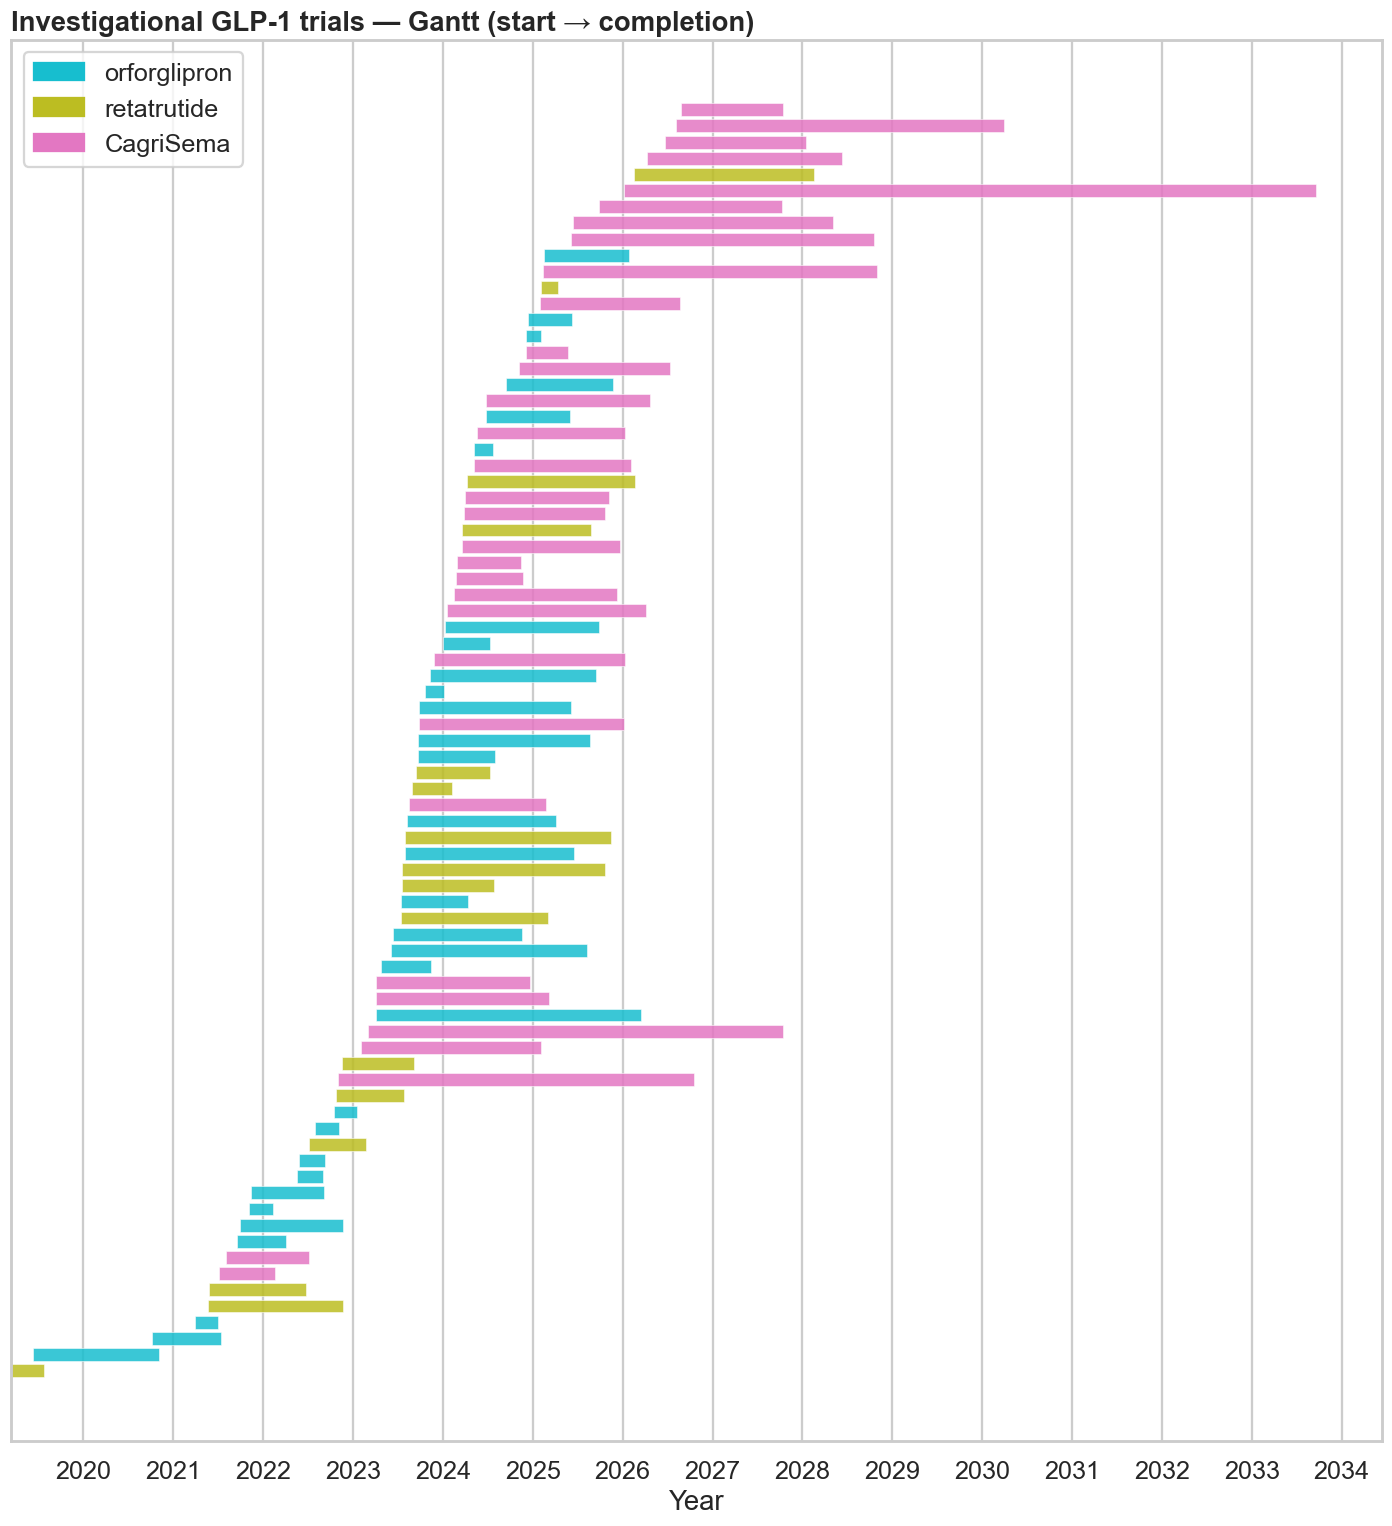

In [7]:
gantt = inv.dropna(subset=["start_date", "completion_date"]).copy()
gantt["duration_days"] = (gantt["completion_date"] - gantt["start_date"]).dt.days
gantt = gantt[gantt["duration_days"] > 0].sort_values("start_date").reset_index(drop=True)
print(f"Trials with valid start+completion dates: {len(gantt):,}")

drug_colors = {"orforglipron": "#17becf", "retatrutide": "#bcbd22", "CagriSema": "#e377c2"}

fig, ax = plt.subplots(figsize=(13, max(6, 0.18 * len(gantt))))
for i, row in gantt.iterrows():
    ax.barh(
        y=i, width=row["duration_days"], left=row["start_date"],
        color=drug_colors.get(row["inv_drug"], "#888"),
        edgecolor="white", linewidth=0.4, alpha=0.85,
    )
ax.set_yticks([])
ax.xaxis.set_major_locator(YearLocator())
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
ax.set_xlabel("Year")
ax.set_title("Investigational GLP-1 trials — Gantt (start → completion)")
legend_handles = [mpatches.Patch(color=c, label=d) for d, c in drug_colors.items() if d in gantt["inv_drug"].unique()]
ax.legend(handles=legend_handles, loc="upper left")
plt.tight_layout()
save_fig(fig, "q6_gantt_timeline")
plt.show()

## 5. Expected-completion-year distribution

Faster read than the Gantt for forecasting: how many trials are expected to wrap in each year?

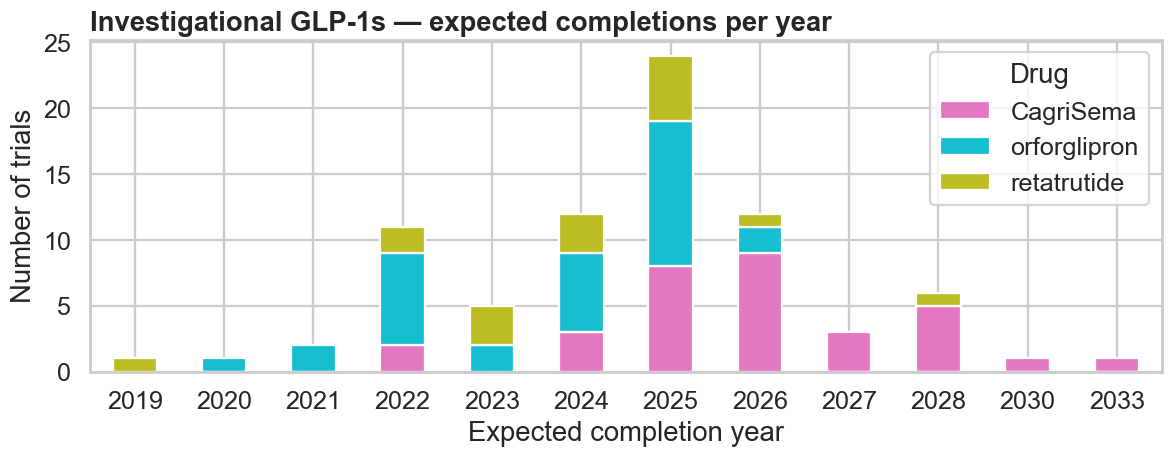

In [8]:
completion = inv.dropna(subset=["completion_date"]).copy()
completion["completion_year"] = completion["completion_date"].dt.year
year_tbl = (
    completion.groupby(["completion_year", "inv_drug"]).size()
              .unstack("inv_drug").fillna(0).astype(int)
)
save_table(year_tbl.reset_index(), "q6_completion_year")

fig, ax = plt.subplots(figsize=(11, 4.5))
year_tbl.plot(kind="bar", stacked=True, ax=ax,
              color=[drug_colors.get(c, "#888") for c in year_tbl.columns])
ax.set_xlabel("Expected completion year")
ax.set_ylabel("Number of trials")
ax.set_title("Investigational GLP-1s — expected completions per year")
ax.legend(title="Drug")
plt.xticks(rotation=0)
plt.tight_layout()
save_fig(fig, "q6_completion_year")
plt.show()

In [9]:
log_path = PROJECT_ROOT / "outputs" / "findings_log.md"
n_by_drug = inv["inv_drug"].value_counts()
active_counts = status_tbl.get("Active", pd.Series(dtype=int))
completed_counts = status_tbl.get("Completed", pd.Series(dtype=int))

entry = f"""
## 07 — Investigational Drugs (Q6)

### Findings
- Trial counts (after expanding the search to `brief_title`): orforglipron={n_by_drug.get('orforglipron', 0)}, retatrutide={n_by_drug.get('retatrutide', 0)}, CagriSema={n_by_drug.get('CagriSema', 0)}.
- Active vs completed (Active / Completed): orforglipron {active_counts.get('orforglipron', 0)}/{completed_counts.get('orforglipron', 0)}, retatrutide {active_counts.get('retatrutide', 0)}/{completed_counts.get('retatrutide', 0)}, CagriSema {active_counts.get('CagriSema', 0)}/{completed_counts.get('CagriSema', 0)}.
- orforglipron leads on volume (oral GLP-1 from Lilly — easier to test = more trials), CagriSema and retatrutide are catching up.
- Most trials expected to read out in **{int(year_tbl.sum(axis=1).idxmax())}** ({int(year_tbl.sum(axis=1).max())} trials).

### Issues / Limitations
- CagriSema is *not* tagged under `drug_query`; recovered only by searching `brief_title` for 'cagrisema' / 'cagrilintide'. Tag-precision is therefore lower for that drug.
- 'First-match wins' tagging means a trial that mentions both retatrutide and orforglipron gets only one tag (CagriSema first, then orforglipron, then retatrutide) — true cross-drug head-to-heads are rare but possible.
- `completion_date` is anticipated for not-yet-completed trials and can slip; the Gantt represents *planned*, not actual, dates for ongoing trials.
- Trials without a `completion_date` are excluded from the Gantt and completion-year charts.

---
"""
with open(log_path, "a", encoding="utf-8") as f:
    f.write(entry)
print("Appended Q6.")

Appended Q6.


## Key Finding

All three investigational drugs have meaningful trial pipelines, with **orforglipron carrying the largest volume** (Lilly's oral candidate), **CagriSema close behind** (Novo's combo with cagrilintide), and **retatrutide running tighter but later-phase**. The bulk of readouts cluster in the 2025-2027 window — meaning the next-generation competitive picture for the GLP-1 weight-loss market is largely going to be set in the next ~24 months.